In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv("./train-test.csv")

In [22]:
for column in data.columns:
    print(column)

load_id
pickup
delivery
pickup_lat
pickup_lon
delivery_lat
delivery_lon
distance
equipment
weight
date
market_index
quote_signal
posted_rate


In [23]:
data[:3]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54


In [24]:
f"We have {len(data)} samples in total."

'We have 48000 samples in total.'

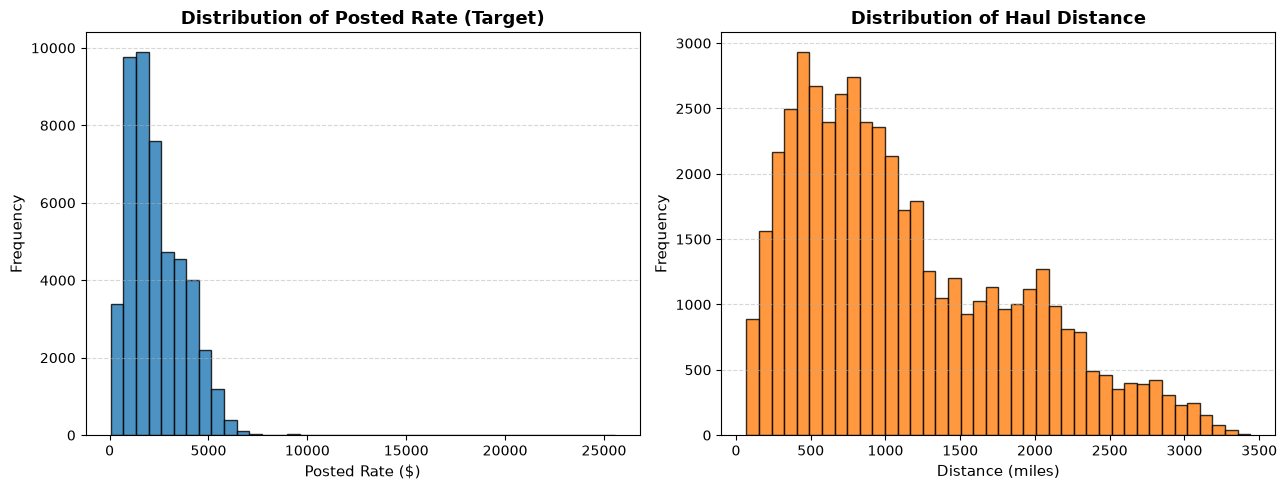

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Target distribution
axes[0].hist(data["posted_rate"].dropna(), bins=40, color="#1f77b4", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribution of Posted Rate (Target)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Posted Rate ($)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 2: Distance distribution
axes[1].hist(data["distance"].dropna(), bins=40, color="#ff7f0e", edgecolor="black", alpha=0.8)
axes[1].set_title("Distribution of Haul Distance", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Distance (miles)", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

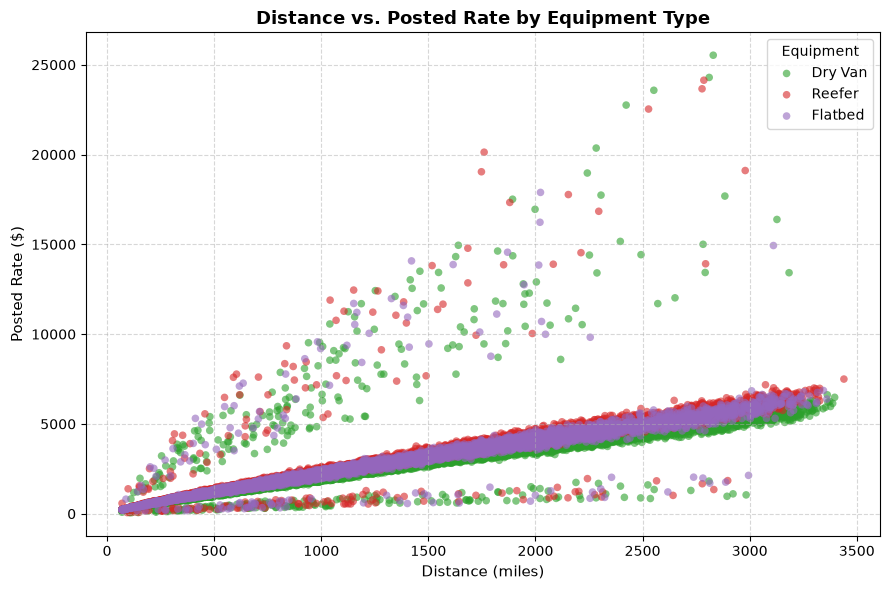

In [27]:
plt.figure(figsize=(9, 6))

equipment_types = data["equipment"].dropna().unique()
colors = ["#2ca02c", "#d62728", "#9467bd", "#8c564b"]

for i, eq in enumerate(equipment_types):
    subset = data[data["equipment"] == eq]
    plt.scatter(
        subset["distance"],
        subset["posted_rate"],
        label=eq,
        alpha=0.6,
        edgecolors="none",
        s=30,
        color=colors[i % len(colors)]
    )

plt.title("Distance vs. Posted Rate by Equipment Type", fontsize=13, fontweight="bold")
plt.xlabel("Distance (miles)", fontsize=11)
plt.ylabel("Posted Rate ($)", fontsize=11)
plt.legend(title="Equipment")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

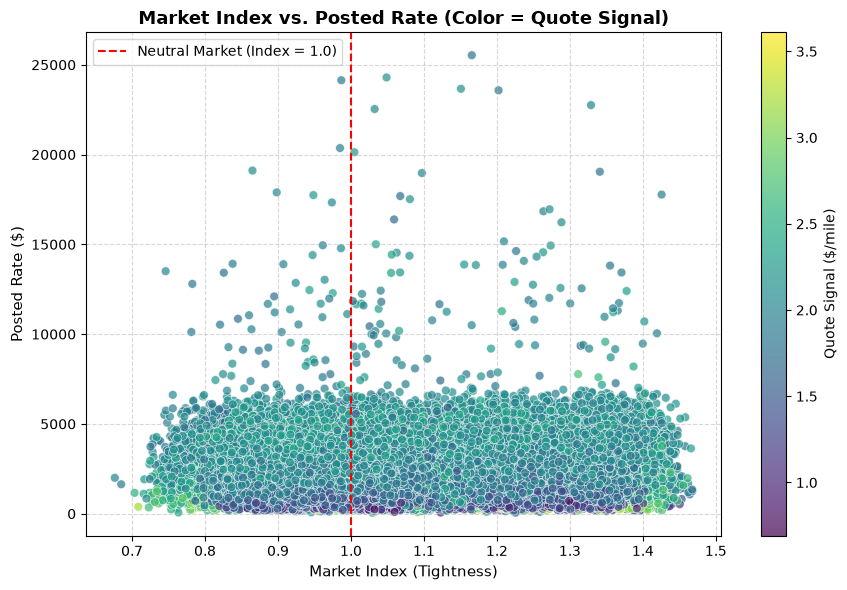

In [28]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    data["market_index"],
    data["posted_rate"],
    c=data["quote_signal"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="w",
    linewidths=0.5,
    s=40
)

cbar = plt.colorbar(scatter)
cbar.set_label("Quote Signal ($/mile)", fontsize=10)

plt.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="Neutral Market (Index = 1.0)")
plt.title("Market Index vs. Posted Rate (Color = Quote Signal)", fontsize=13, fontweight="bold")
plt.xlabel("Market Index (Tightness)", fontsize=11)
plt.ylabel("Posted Rate ($)", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

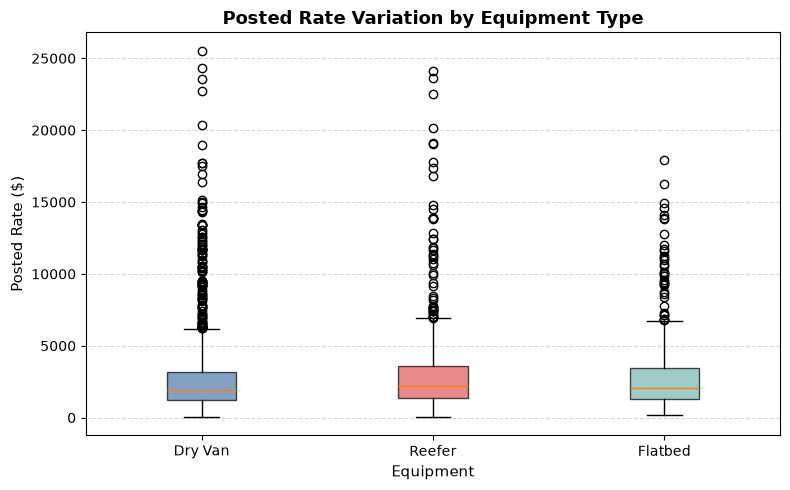

In [29]:
plt.figure(figsize=(8, 5))

equipment_categories = [eq for eq in data["equipment"].dropna().unique()]
rates_per_equipment = [data[data["equipment"] == eq]["posted_rate"].dropna() for eq in equipment_categories]

box = plt.boxplot(rates_per_equipment, tick_labels=equipment_categories, patch_artist=True)

box_colors = ["#4e79a7", "#e15759", "#76b7b2", "#59a14f"]
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Posted Rate Variation by Equipment Type", fontsize=13, fontweight="bold")
plt.xlabel("Equipment", fontsize=11)
plt.ylabel("Posted Rate ($)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()